<a href="https://colab.research.google.com/github/wisesprout/project1_vgames/blob/main/Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

불러오기

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames2.csv', index_col = 0)
df.head()
df = df.dropna()  # na 값 있는 데이터 제외

# 1. preprocessing vgames2
1 - 1) Publisher 전처리

In [33]:
df['Publisher'].unique()
pd.set_option('display.max_rows', None)  # value_counts 모든 값
df['Publisher'].value_counts()  # 99개의 'Unknown' 값 확인
df[df['Publisher']=='Unknown']  # 결과를 조사해보니 'Unknown Wordls Entertainment'가 아님을 확인
df.drop(df[df['Publisher']=='Unknown'].index, inplace = True)
df[df['Publisher']=='Unknown']  # drop한 결과 확인

,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales


1 - 2) Year 전처리

In [34]:
# Year 정리

# df['Year'] = df['Year'].astype(int) 이건 왜 안되고 밑줄은 되지???
df.Year = df.Year.astype(int)
# Year가 4자리 아니면 drop
i = 0
while i < len(df['Year']):
    digit = 0
    year = df.iloc[i,2]
    while(year > 0):  # 10으로 계속 나눠서 자릿수 확인
        digit += 1
        year //= 10
    if digit != 4:
        df.drop(df.index[i], inplace = True)
    else:
        i += 1

df['Year'].unique()  # drop한 결과 확인

array([2008, 2009, 2010, 2005, 2011, 2007, 2001, 2003, 2006, 2014, 2015,
       2002, 1997, 2013, 1996, 2004, 2000, 1984, 1998, 2016, 1985, 1999,
       1995, 1993, 2012, 1987, 1982, 1994, 1990, 1992, 1991, 1983, 1988,
       1981, 1989, 1986, 2017, 1980, 2020])

1 - 3) Sales 단위 10,000으로 통일

In [35]:
# 단위 10,000으로 통일
for j in range(5,9):
  # j번째 컬럼의 단위를 숫자로 변경
  for i in range(len(df.iloc[:,j])):
    if ('K' in df.iloc[i,j]):  # j번째 컬럼의 i번째 값이 K를 포함하면
      df.iloc[i,j] = float(df.iloc[i,j].replace('K',''))/10**3  # K 삭제, 10^3으로 나누기, str->float
    elif ('M' in df.iloc[i,j]):  # j번째 컬럼의 i번째 값이 M을 포함하면
      df.iloc[i,j] = float(df.iloc[i,j].replace('M',''))  # M 삭제, str->float
    else:
      df.iloc[i,j] = float(df.iloc[i,j])  # K, M 없는 값은 str->float
  df.iloc[:,j] = (df.iloc[:,j]*100).astype(int)  # j번째 컬럼 전체 float->int

df.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_a.xlsx', index = False)

In [36]:
# 나머지 feature 값 확인
df['Platform'].value_counts()
df['Genre'].value_counts()
df['Genre'].unique()

array(['Action', 'Adventure', 'Misc', 'Platform', 'Sports', 'Simulation',
       'Racing', 'Role-Playing', 'Puzzle', 'Strategy', 'Fighting',
       'Shooter'], dtype=object)

# 2. 지역에 따라 선호하는 장르가 다를까?

In [37]:
'''tidy_df2 = pd.melt(df, id_vars = ['Genre'], var_name = 'Sales', value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], value_name = 'Sum')
tidy_df2 = tidy_df2.sort_values(by = 'Genre')
check_df2 = pd.pivot_table(tidy_df2, index = ['Sales'], columns = 'Genre', aggfunc = np.sum)
check_df2.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_df2.xlsx')
check_df2
tidy_df2.head(10)'''

"tidy_df2 = pd.melt(df, id_vars = ['Genre'], var_name = 'Sales', value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], value_name = 'Sum')\ntidy_df2 = tidy_df2.sort_values(by = 'Genre')\ncheck_df2 = pd.pivot_table(tidy_df2, index = ['Sales'], columns = 'Genre', aggfunc = np.sum)\ncheck_df2.to_excel('/content/drive/MyDrive/Colab Notebooks/Section1/Project/vgames_df2.xlsx')\ncheck_df2\ntidy_df2.head(10)"

지역별 출고량 top 5인 장르

In [38]:
# 전체 데이터에서 지역별 장르의 출고량 데이터 추출

region_sum = ['NA_sum', 'EU_sum', 'JP_sum', 'Other_sum']
genre = ['Action', 'Adventure', 'Misc', 'Platform', 'Sports', 'Simulation', 'Racing', 'Role-Playing', 'Puzzle', 'Strategy', 'Fighting', 'Shooter']
df2 = pd.DataFrame(columns = genre, index = region_sum).fillna(0)
for i in range(len(df['NA_Sales'])):
    df_genre = df.iloc[i,3]
    if df_genre == 'Action':    # i번째 인덱스의 Genre = Action이면
        for j in range(0,4):
            df2.iloc[j,0] += df.iloc[i,j+5]  # df2의 Action 컬럼에 순서대로 값 추가
    elif df_genre == 'Adventure':
        for j in range(0,4):
            df2.iloc[j,1] += df.iloc[i,j+5]
    elif df_genre == 'Misc':
        for j in range(0,4):
            df2.iloc[j,2] += df.iloc[i,j+5]
    elif df_genre == 'Platform':
        for j in range(0,4):
            df2.iloc[j,3] += df.iloc[i,j+5]
    elif df_genre == 'Sports':
        for j in range(0,4):
            df2.iloc[j,4] += df.iloc[i,j+5]
    elif df_genre == 'Simulation':
        for j in range(0,4):
            df2.iloc[j,5] += df.iloc[i,j+5]
    elif df_genre == 'Racing':
        for j in range(0,4):
            df2.iloc[j,6] += df.iloc[i,j+5]
    elif df_genre == 'Role-Playing':
        for j in range(0,4):
            df2.iloc[j,7] += df.iloc[i,j+5]
    elif df_genre == 'Puzzle':
        for j in range(0,4):
            df2.iloc[j,8] += df.iloc[i,j+5]
    elif df_genre == 'Strategy':
        for j in range(0,4):
            df2.iloc[j,9] += df.iloc[i,j+5]
    elif df_genre == 'Fighting':
        for j in range(0,4):
            df2.iloc[j,10] += df.iloc[i,j+5]
    else:
        for j in range(0,4):
            df2.iloc[j,11] += df.iloc[i,j+5]
    
df2


,Action,Adventure,Misc,Platform,Sports,Simulation,Racing,Role-Playing,Puzzle,Strategy,Fighting,Shooter
NA_sum,85411,10092,39298,44224,66306,18096,35332,30557,12068,6777,21998,57045
EU_sum,51158,6324,20682,19914,36942,11253,23293,17575,5014,4457,9962,30702
JP_sum,15463,5137,10357,12920,13444,6345,5499,33471,5612,4805,8633,3732
Other_sum,18346,1661,7236,5108,13156,3120,7588,5452,1236,1119,3607,10075


In [39]:
'''#df2_tidy = pd.melt(df2, id_vars = df2.index, value_vars = genre, var_name= 'Region')
#df2_tidy = pd.melt(df, id_vars = ['Genre'], var_name = 'Sales', value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], value_name = 'Sum')
#df2_tidy
df2g = df.groupby(by = ['Sales','Genre']).sum()
df2g'''

"#df2_tidy = pd.melt(df2, id_vars = df2.index, value_vars = genre, var_name= 'Region')\n#df2_tidy = pd.melt(df, id_vars = ['Genre'], var_name = 'Sales', value_vars = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales'], value_name = 'Sum')\n#df2_tidy\ndf2g = df.groupby(by = ['Sales','Genre']).sum()\ndf2g"

In [40]:
# 추출한 데이터에서 상위 5순위 출력

df2_top = pd.DataFrame(index = region_sum, columns = ['Top1','Top2','Top3','Top4','Top5']).fillna(0)
for j in range(0,4):  # df2에서 지역별 장르 판매량 내림차순
    # region's top genre = rtg
    rtg = df2.iloc[j].sort_values(ascending = False)
    #print(j,'번째 지역',rtg.index)
    for i in range (0,5):
        # j번째 지역의 장르 순위대로 대입
         df2_top.iloc[j,i] = rtg.index[i]
    
df2_top

,Top1,Top2,Top3,Top4,Top5
NA_sum,Action,Sports,Shooter,Platform,Misc
EU_sum,Action,Sports,Shooter,Racing,Misc
JP_sum,Role-Playing,Action,Sports,Platform,Misc
Other_sum,Action,Sports,Shooter,Racing,Misc


([<matplotlib.patches.Wedge at 0x7f29848139d0>,
 [Text(0.8900603501278644, 0.6463687594015226, '18346'),
  Text(0.26188155123227147, 1.06837168304115, '13156'),
  Text(-0.13476695094318286, 1.0917132723080167, '10075'),
  Text(-0.7393024656094087, 0.8145132683657457, '7588'),
  Text(-1.0997587574049392, 0.023036395359173924, '7236'),
  Text(-0.9080333495573225, -0.6208666814153498, '5452'),
  Text(-0.6011317556885372, -0.9212169192447656, '5108'),
  Text(-0.10283360995883976, -1.0951827466970219, '3607'),
  Text(0.23987643615586754, -1.0735265694789116, '3120'),
  Text(0.3858737137954836, -1.030097799726648, '1661'),
  Text(0.5936194133648169, -0.9260755865891351, '1236'),
  Text(1.0046219043484574, -0.44803440638334807, '1119')])

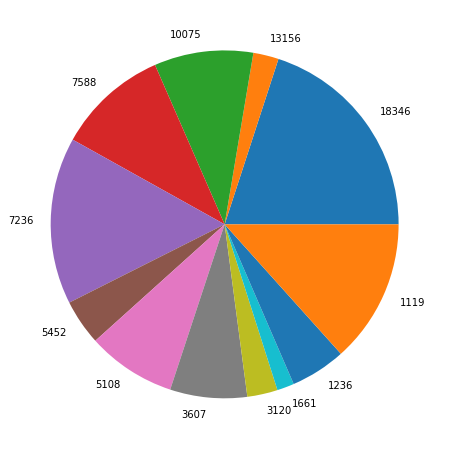

In [41]:
# 시각화
fig = plt.figure(figsize = (8, 8))  # 배경
fig.set_facecolor('white')
ax = fig.add_subplot()  # 기본 위치
ax.pie(x = df2.iloc[0], labels = rtg)
#df2.plot(kind = 'pie', y = '')